# Zero-Noise Extrapolation (ZNE) with Indirect-Control System
---

This experiment is:

- Qubit: 7, layer: 30
- System has noise-free time evolution.
- Target observable: Transverse field Ising Hamiltonian.
- Ansatz time-evolution: Noisy XY time-evolution.
- Time-constraint: True

## (1) Import and setup

In [1]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import json
import textwrap
import importlib
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped

In [2]:
# Set the default font to be LaTeX compliant.
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Computer Modern Roman"
plt.rcParams["text.usetex"] = True

# Set a global font size.
font_size = 11
plt.rcParams["font.size"] = font_size
plt.rcParams["axes.labelsize"] = font_size
plt.rcParams["xtick.labelsize"] = font_size
plt.rcParams["ytick.labelsize"] = font_size
plt.rcParams["legend.fontsize"] = 10

In [3]:
BASE_PATH = "data"

ZNE_MODELS = [
    "xy-ric2",
    "xy-ric3",
    "xy-ric4",
    "xy-ric5",
    "xy-ric6",
    "xy-ric7",
]

JSON_ENDS_WITH = {
    "vqe": "_vqe.json",
    "redundant": "_redundant.json",
    "zne": "_zne.json",
    "noiseoff": "_noise_off.json"
}

plot_colors = [
    "darkred",
    "darkgreen",
    "darkblue",
    "darkmagenta",
    "darkcyan",
    "magenta",
    "green",
    "goldenrod",
    "black",
    "orange",
    "purple"
]

pdf_reports: bool = True
# Detailed report can take some times
detailed_reports: bool = False

timestamp: str = datetime.now().strftime("%Y%m%d-%H%M%S")
plot_dir: str = f"reports/{timestamp}/plots"
artifact_dir: str = f"reports/{timestamp}/artifacts"

## (2) Loading the experimental data from JSON files

The raw experimenal data are availabe at `data\` folder

In [4]:
# Storage
ALL_RAW_DATA = {
    model: {key: [] for key in JSON_ENDS_WITH}
    for model in ZNE_MODELS
}

# Load loop
for model in ZNE_MODELS:
    model_path = os.path.join(BASE_PATH, model)
    if not os.path.isdir(model_path):
        print(f"[WARNING] Skipping missing dir: {model_path}")
        continue
    
    for filename in os.listdir(model_path):
        if not filename.endswith(".json"):
            continue
        
        filepath = os.path.join(model_path, filename)
        try:
            with open(filepath, "r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:
            print(f"[ERROR] {filepath}: {e}")
            continue
        
        filename_lower = filename.lower()
        for key, suffix in JSON_ENDS_WITH.items():
            if filename_lower.endswith(suffix):
                ALL_RAW_DATA[model][key].append(data)
                break

## (3) Extracting data

<img src="../../figures/quantum_cicuit_standard_vs_redundant.jpg" alt="std_vs_redun_circuit" width="800"/>


Now lets extract some unformations.

### (A) The exact minimum eigen value

Our target Hamiltonian is

$$H_{Ising} = \sum_{k=1}^{N-1} X_{k}X_{k+1} + \sum_{k=1}^{N}Z_k$$

where $N=7$.

The exact minimum eigen value of the target observable (i.e. tranverse field Ising Hamiltonian for a 7-qubit system) is $-8.566772233505624$. This value is recored in `file_name_prefix_ZNE.json` files.

In [5]:
EXACT_SOL: float = -8.566772233505624
EXTRAPOL_TARGET = 0.0  # Extrapolated noise level
print(f"Exact solution: {EXACT_SOL}")

Exact solution: -8.566772233505624


### (B) VQE estimations (noise is on)

The noise level ($\lambda$) is defined as 
$$\lambda = n_R + 2 n_{CZ} + N n_T + n_Y$$

where $nR, n_{CZ}, n_T, $ and $nY$ are proportinal to number of *noisy* rotation gates, two-qubit $CZ$ gate, the time-evolution gates, and Y gates. For the above circuit in the standard circuit (i.e. unboosted noise) noise level is $6$ while in the redundant circuit (i.e. boosted noise) noise level is $18$.

### (C) Processing raw data

In [6]:
ALL_PROCESSED_DATA = {
    model: {
        "vqe": {},
        "redundant": {},
        "zne": {},
        "noiseoff": {}
    } for model in ZNE_MODELS
}

for model in ZNE_MODELS:
    
    ALL_PROCESSED_DATA[model]["vqe"] = {
        "mean": np.mean(
            ALL_RAW_DATA[model]["vqe"][0]["output"]["optimized_minimum_cost"]
        ),
        "std": np.std(
            ALL_RAW_DATA[model]["vqe"][0]["output"]["optimized_minimum_cost"]
        )
    }
    # Based off the ZNE model, length of data points can be arbitrary
    n_levels = len(ALL_RAW_DATA[model]["redundant"][0]["output"]["data_points"])
    ALL_PROCESSED_DATA[model]["redundant"] = {
        "sorted_noise_levels": ALL_RAW_DATA[model]["zne"][0]["output"]["zne_values"]["others"]["sorted_noise"],
        "mean": [
            np.mean([
                ALL_RAW_DATA[model]["redundant"][i]["output"]["data_points"][level][4]
                for i in range(len(ALL_RAW_DATA[model]["redundant"]))
            ])
            for level in range(n_levels)
        ],
        "std": [
            np.std([
                ALL_RAW_DATA[model]["redundant"][i]["output"]["data_points"][level][4]
                for i in range(len(ALL_RAW_DATA[model]["redundant"]))
            ])
            for level in range(n_levels)
        ],
    }
   
    ALL_PROCESSED_DATA[model]["zne"] = {
        "mean": np.mean(
            [ALL_RAW_DATA[model]["zne"][i]["output"]["zne_values"]["extrapolated_value"] for i in range(len(ALL_RAW_DATA[model]["zne"]))]
        ),
        "std": np.std(
            [ALL_RAW_DATA[model]["zne"][i]["output"]["zne_values"]["extrapolated_value"] for i in range(len(ALL_RAW_DATA[model]["zne"]))]
        )
    }

    ALL_PROCESSED_DATA[model]["noiseoff"] = {
        "mean": np.mean(
            ALL_RAW_DATA[model]["noiseoff"][0]["output"]["optimized_minimum_cost"]
        ),
        "std": np.std(
            ALL_RAW_DATA[model]["noiseoff"][0]["output"]["optimized_minimum_cost"]
        )
    }

In [7]:
# Prepare rows for tabulation
rows = []
for model, methods in ALL_PROCESSED_DATA.items():
    for method, stats in methods.items():
        if method == "redundant":
            for lvl, m, s in zip(stats['sorted_noise_levels'], stats['mean'], stats['std']):
                rows.append([model, f"{method} (noise={lvl})", m, s])
        elif stats:  # ignore empty "noiseoff"
            rows.append([model, method, stats['mean'], stats['std']])
        else:
            rows.append([model, method, "N/A", "N/A"])

# Print table
headers = ["Model", "Category", "Mean", "Std"]
print(tabulate(rows, headers=headers))

Model    Category                  Mean        Std
-------  --------------------  --------  ---------
xy-ric2  vqe                   -8.09328  0.0658466
xy-ric2  redundant (noise=7)   -8.09328  0.0658466
xy-ric2  redundant (noise=21)  -7.8473   0.0615238
xy-ric2  zne                   -8.21628  0.071318
xy-ric2  noiseoff              -8.36934  0.15125
xy-ric3  vqe                   -8.09328  0.0658466
xy-ric3  redundant (noise=7)   -8.09328  0.0658466
xy-ric3  redundant (noise=21)  -7.8473   0.0615238
xy-ric3  redundant (noise=35)  -7.61821  0.0665639
xy-ric3  zne                   -8.22261  0.0714201
xy-ric3  noiseoff              -8.36934  0.15125
xy-ric4  vqe                   -8.09328  0.0658466
xy-ric4  redundant (noise=7)   -8.09328  0.0658466
xy-ric4  redundant (noise=21)  -7.8473   0.0615238
xy-ric4  redundant (noise=35)  -7.61821  0.0665639
xy-ric4  redundant (noise=49)  -7.40514  0.078563
xy-ric4  zne                   -8.22289  0.0714376
xy-ric4  noiseoff              -8.369

## (4) Plot the results

Finally we can plot the results.

### #1 xy-ric2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20260323-122557/plots' folder): xy_ric2.eps
{'vqe': {'mean': -8.093283273804532, 'std': 0.06584664640469055},
 'redundant': {'sorted_noise_levels': [7, 21],
               'mean': [-8.093283273804463, -7.84729587457304],
               'std': [0.06584664640468443, 0.06152376169094523]},
 'zne': {'mean': -8.216276973420173, 'std': 0.07131801390423902},
 'noiseoff': {'mean': -8.369342611101047, 'std': 0.15124979844206457}}


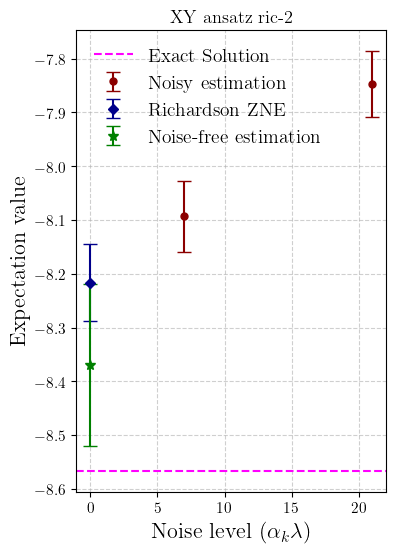

In [8]:
xy_ric2_plt = plot_zne_result(
    data=ALL_PROCESSED_DATA["xy-ric2"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="XY ansatz ric-2",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="xy_ric2.eps",
)

### #2 xy-ric3-plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20260323-122557/plots' folder): xy_ric3.eps
{'vqe': {'mean': -8.093283273804532, 'std': 0.06584664640469055},
 'redundant': {'sorted_noise_levels': [7, 21, 35],
               'mean': [-8.093283273804461,
                        -7.847295874573038,
                        -7.618209636997703],
               'std': [0.0658466464046843,
                       0.06152376169094527,
                       0.06656385914591355]},
 'zne': {'mean': -8.222614909041207, 'std': 0.07142009023294436},
 'noiseoff': {'mean': -8.369342611101047, 'std': 0.15124979844206457}}


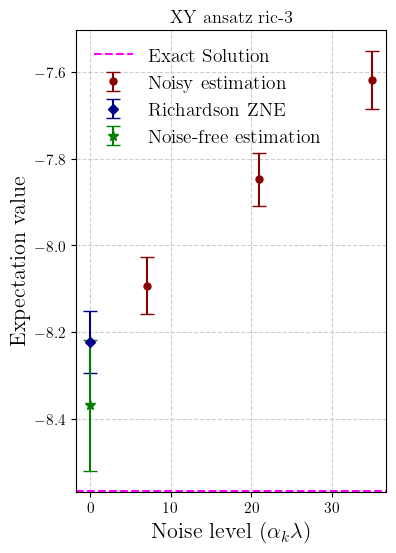

In [9]:
xy_ric3_plt = plot_zne_result(
    data=ALL_PROCESSED_DATA["xy-ric3"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="XY ansatz ric-3",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="xy_ric3.eps",
)

### #3 xy-ric4 plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20260323-122557/plots' folder): xy_ric4.eps
{'vqe': {'mean': -8.093283273804532, 'std': 0.06584664640469055},
 'redundant': {'sorted_noise_levels': [7, 21, 35, 49],
               'mean': [-8.093283273804461,
                        -7.847295874573038,
                        -7.618209636997705,
                        -7.405139011224709],
               'std': [0.06584664640468442,
                       0.06152376169094514,
                       0.06656385914591363,
                       0.07856299978405779]},
 'zne': {'mean': -8.222891643370502, 'std': 0.0714375885763562},
 'noiseoff': {'mean': -8.369342611101047, 'std': 0.15124979844206457}}


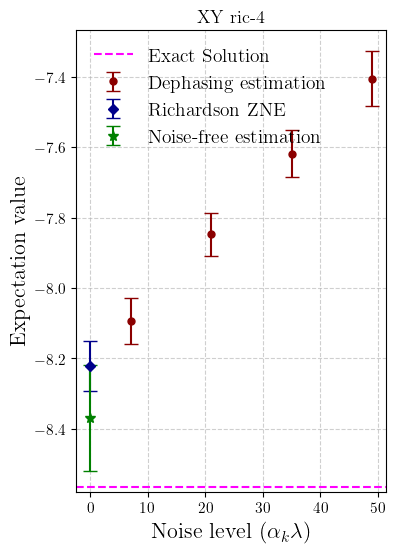

In [10]:
xy_ric4 = plot_zne_result(
    data=ALL_PROCESSED_DATA["xy-ric4"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="XY ric-4",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="xy_ric4.eps",
    leg_noise_type="Dephasing",
    legend_loc="upper left"
)

### #4 xy-ric5 plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20260323-122557/plots' folder): xy_ric5.eps
{'vqe': {'mean': -8.093283273804532, 'std': 0.06584664640469055},
 'redundant': {'sorted_noise_levels': [7, 21, 35, 49, 63],
               'mean': [-8.093283273804463,
                        -7.847295874573038,
                        -7.618209636997705,
                        -7.4051390112247075,
                        -7.207258187929677],
               'std': [0.06584664640468438,
                       0.06152376169094533,
                       0.0665638591459134,
                       0.0785629997840578,
                       0.09459456137408749]},
 'zne': {'mean': -8.222907978671506, 'std': 0.07143834802106441},
 'noiseoff': {'mean': -8.369342611101047, 'std': 0.15124979844206457}}


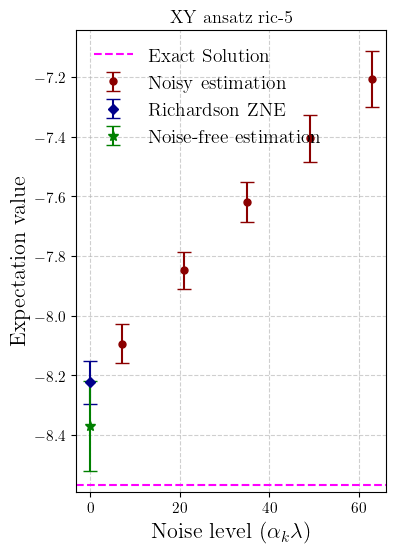

In [11]:
xy_ric5 = plot_zne_result(
    data=ALL_PROCESSED_DATA["xy-ric5"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="XY ansatz ric-5",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="xy_ric5.eps",
)

### #5 xy-ric6 plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20260323-122557/plots' folder): xy_ric6.eps
{'vqe': {'mean': -8.093283273804532, 'std': 0.06584664640469055},
 'redundant': {'sorted_noise_levels': [7, 21, 35, 49, 63, 77],
               'mean': [-8.093283273804461,
                        -7.84729587457304,
                        -7.618209636997703,
                        -7.405139011224709,
                        -7.2072581879296775,
                        -7.023796416274264],
               'std': [0.06584664640468418,
                       0.06152376169094506,
                       0.06656385914591323,
                       0.078562999784058,
                       0.0945945613740876,
                       0.1128295079051112]},
 'zne': {'mean': -8.222909130893107, 'std': 0.0714384179300456},
 'noiseoff': {'mean': -8.369342611101047, 'std': 0.15124979844206457}}


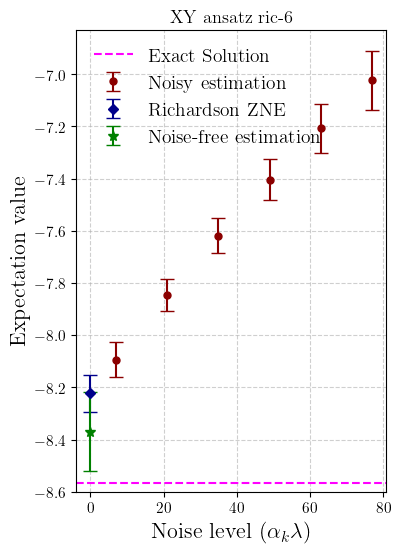

In [12]:
xy_ric6 = plot_zne_result(
    data=ALL_PROCESSED_DATA["xy-ric6"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="XY ansatz ric-6",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="xy_ric6.eps",
)

### #6 xy-ric7 plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Figure saved as (in 'reports/20260323-122557/plots' folder): xy_ric7.eps
{'vqe': {'mean': -8.093283273804532, 'std': 0.06584664640469055},
 'redundant': {'sorted_noise_levels': [7, 21, 35, 49, 63, 77, 91],
               'mean': [-8.093283273804463,
                        -7.847295874573038,
                        -7.618209636997703,
                        -7.405139011224709,
                        -7.2072581879296775,
                        -7.023796416274264,
                        -6.854033496745545],
               'std': [0.065846646404684,
                       0.06152376169094463,
                       0.06656385914591346,
                       0.07856299978405788,
                       0.09459456137408755,
                       0.11282950790511144,
                       0.13235855540414732]},
 'zne': {'mean': -8.222909170344192, 'std': 0.07143842424224794},
 'noiseoff': {'mean': -8.369342611101047, 'std': 0.15124979844206457}}


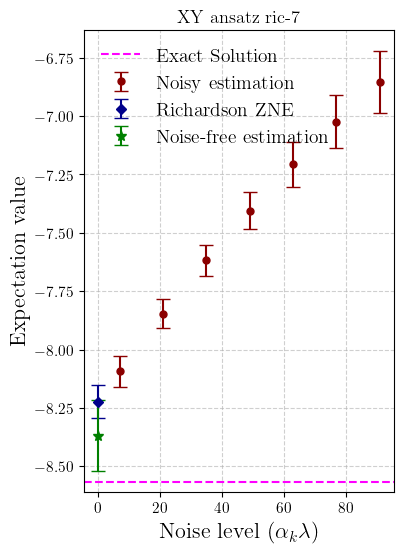

In [13]:
xy_ric7 = plot_zne_result(
    data=ALL_PROCESSED_DATA["xy-ric7"],
    extrapol_target=EXTRAPOL_TARGET,
    exact_solution=EXACT_SOL,
    plot_colors=plot_colors,
    plot_title="XY ansatz ric-7",
    output_dir=f"reports/{timestamp}/plots",
    plot_file_name="xy_ric7.eps",
)

### #7 Compiled ric-2 plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Compiled figure saved: reports/20260323-122557/plots/compiled_ric3.eps


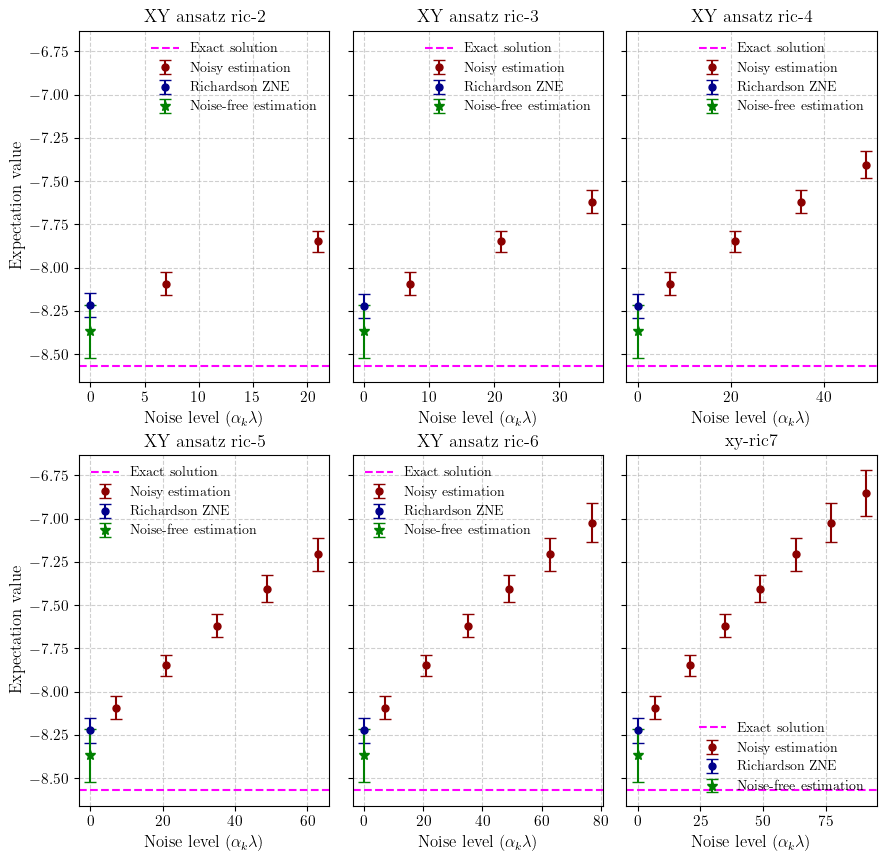

In [14]:
plot_titles = {
    "xy-ric2": "XY ansatz ric-2",
    "xy-ric3": "XY ansatz ric-3",
    "xy-ric4": "XY ansatz ric-4",
    "xy-ric5": "XY ansatz ric-5",
    "xy-ric6": "XY ansatz ric-6",
}

models_to_plot = ZNE_MODELS

xy_compiled_plt = compile_zne_subplots(
    data=ALL_PROCESSED_DATA,
    models=models_to_plot,
    plot_titles=plot_titles,
    plot_colors=plot_colors,
    exact_solution=EXACT_SOL,
    extrapol_target=EXTRAPOL_TARGET,
    ncols=3,
    figsize=(9, 9),
    output_dir=f"reports/{timestamp}/plots",
    filename_prefix="compiled_ric3"
)

## (7) Summary

=== Summary Table ===
   Description            Simulation          Mean ± Std
0      xy-ric2                   vqe  -8.09328 ± 0.06585
1      xy-ric2   redundant (noise=7)  -8.09328 ± 0.06585
2      xy-ric2  redundant (noise=21)  -7.84730 ± 0.06152
3      xy-ric2                   zne  -8.21628 ± 0.07132
4      xy-ric2              noiseoff  -8.36934 ± 0.15125
5                                                       
6      xy-ric3                   vqe  -8.09328 ± 0.06585
7      xy-ric3   redundant (noise=7)  -8.09328 ± 0.06585
8      xy-ric3  redundant (noise=21)  -7.84730 ± 0.06152
9      xy-ric3  redundant (noise=35)  -7.61821 ± 0.06656
10     xy-ric3                   zne  -8.22261 ± 0.07142
11     xy-ric3              noiseoff  -8.36934 ± 0.15125
12                                                      
13     xy-ric4                   vqe  -8.09328 ± 0.06585
14     xy-ric4   redundant (noise=7)  -8.09328 ± 0.06585
15     xy-ric4  redundant (noise=21)  -7.84730 ± 0.06152
16     xy

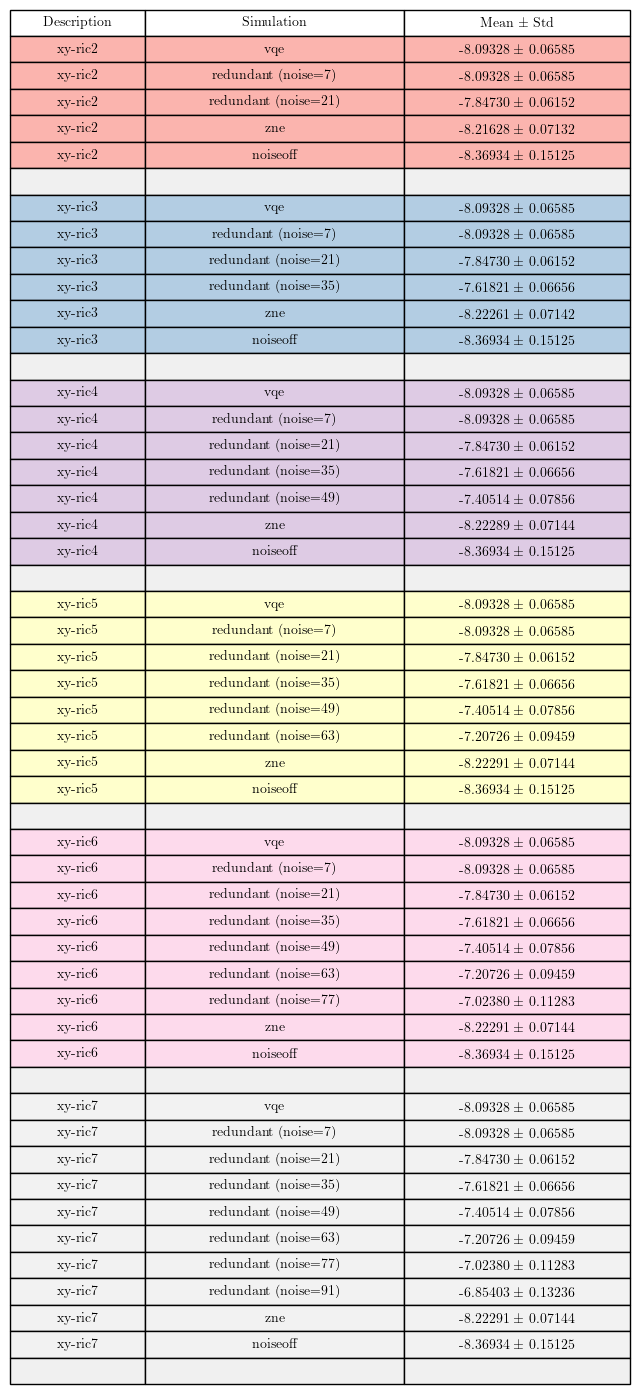

In [15]:
df_summary, fig = summarize_zne_results(
    ALL_PROCESSED_DATA=ALL_PROCESSED_DATA,
    selected_models=ZNE_MODELS,
    decimals=5,
    font_size=10,
    row_scale=1.3,
    output_dir=f"reports/{timestamp}/artifacts",
    save_name=f"zne_summary",
    save_formats=["txt","eps","csv","latex"]
)

# Appendix
---

### PDF report

In [16]:
CONFIG_SUMMARY: dict = {
    "xy": ALL_RAW_DATA["xy-ric2"]["vqe"][0]["config"],
}
ALL_PLOTS = [
    xy_compiled_plt
]

In [17]:
HEIGHT = 0.2
WIDTH = 5
FILE_NAME = f"reports/{timestamp}/artifacts/zne_summary.pdf"

# Flatten deeply nested dicts
def flatten_config(config, prefix=""):
    flat = {}
    for k, v in config.items():
        full_key = f"{prefix}{k}"
        if isinstance(v, dict):
            flat.update(flatten_config(v, prefix=full_key + "."))
        else:
            flat[full_key] = v
    return flat

def render_model_config_page(model_name, config_dict):
    flat_config = flatten_config(config_dict)
    df = pd.DataFrame(list(flat_config.items()), columns=["Parameter", "Value"])

    # Estimate height dynamically
    row_height = HEIGHT  # inches per row
    max_width = WIDTH  # keep A4 landscape width if needed
    fig_height = max(2, min(len(df) * row_height + 1.5, 11))

    fig = plt.figure(figsize=(max_width, fig_height))
    ax = fig.add_axes([0, 0, 1, 1])  # Full area, no margin
    ax.axis('off')

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='left',
        loc='center',
    )

    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1, 1.3)  # Adjust row height for readability

    # Color header row
    for j in range(len(df.columns)):
        table[(0, j)].set_fontsize(9)
        table[(0, j)].set_facecolor("#dddddd")
        table[(0, j)].set_text_props(weight='bold')

    # Add title manually
    fig.text(0.5, 0.98, f"{model_name.upper()} VQE CONFIGURATION", ha='center', fontsize=12, weight='bold')

    return fig

if pdf_reports:
    with PdfPages(FILE_NAME) as pdf:
        # Save a main figure (if any)
        pdf.savefig(fig, bbox_inches='tight', pad_inches=0.05)
        plt.close(fig)
        
        # Save multiple stored figures
        for stored_fig in ALL_PLOTS:
            pdf.savefig(stored_fig, bbox_inches='tight', pad_inches=0.05)
            plt.close(stored_fig)
        
        # Save config summary pages
        for model, config in CONFIG_SUMMARY.items():
            config_fig = render_model_config_page(model, config)
            pdf.savefig(config_fig, bbox_inches='tight', pad_inches=0.1)
            plt.close(config_fig)
        
        print("Result summary saved as PDF:", FILE_NAME)
else:
    print("PDF report generation skipped.")

Result summary saved as PDF: reports/20260323-122557/artifacts/zne_summary.pdf


In [18]:
if detailed_reports:
    export_raw_data_wrapped(ALL_RAW_DATA, pdf_filename=f"reports/{timestamp}/artifacts/big_json.pdf")
else:
    print("Detailed raw data PDF export skipped.")

Detailed raw data PDF export skipped.


### Latex table

In [19]:
def generate_latex_table_ric4(all_data):
    """
    Generate a ready-to-copy LaTeX table for ric4 results (XY only).
    Uses inline math $...$ with \pm.
    """
    def fmt(m, s):
        return f"${m:.3f} \\pm {s:.3f}$"

    # Pick ric4 key (XY only)
    xy_key = [k for k in all_data if k.startswith("xy") and "ric4" in k][0]

    table = r"""\begin{table}[h]
\caption{!!!!!TABLE CAPTION HERE!!!!! The corresponding plots are shown in Figure \ref{graph-noisefree-timevo}.}
\begin{tabular}{@{}ll@{}}
\toprule
  & XY-ansatz\\
\midrule
"""

    # Noise-free estimation
    table += f"Noise-free estimation & {fmt(all_data[xy_key]['noiseoff']['mean'], all_data[xy_key]['noiseoff']['std'])} \\\\\n"
    table += r"\midrule" + "\n"

    # Boosted noise levels
    noise_levels = all_data[xy_key]['redundant']['sorted_noise_levels']
    means = all_data[xy_key]['redundant']['mean']
    stds = all_data[xy_key]['redundant']['std']

    for i, nl in enumerate(noise_levels):
        table += f"***Boosted noise****={nl} & {fmt(means[i], stds[i])} \\\\\n"

    table += r"\midrule" + "\n"

    # Richardson ZNE result
    table += f"Richardson ZNE value & {fmt(all_data[xy_key]['zne']['mean'], all_data[xy_key]['zne']['std'])} \\\\\n"

    table += r"""\bottomrule
\end{tabular}
\label{table-noisy-timeevo-richardson}
\end{table}"""

    return table


# Usage:
latex_table_ric4 = generate_latex_table_ric4(ALL_PROCESSED_DATA)
print(latex_table_ric4)

\begin{table}[h]
\caption{!!!!!TABLE CAPTION HERE!!!!! The corresponding plots are shown in Figure \ref{graph-noisefree-timevo}.}
\begin{tabular}{@{}ll@{}}
\toprule
  & XY-ansatz\\
\midrule
Noise-free estimation & $-8.369 \pm 0.151$ \\
\midrule
***Boosted noise****=7 & $-8.093 \pm 0.066$ \\
***Boosted noise****=21 & $-7.847 \pm 0.062$ \\
***Boosted noise****=35 & $-7.618 \pm 0.067$ \\
***Boosted noise****=49 & $-7.405 \pm 0.079$ \\
\midrule
Richardson ZNE value & $-8.223 \pm 0.071$ \\
\bottomrule
\end{tabular}
\label{table-noisy-timeevo-richardson}
\end{table}


### Grid plotting

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ ZNE grid saved to: reports/20260323-122557/plots/grid_plot.eps


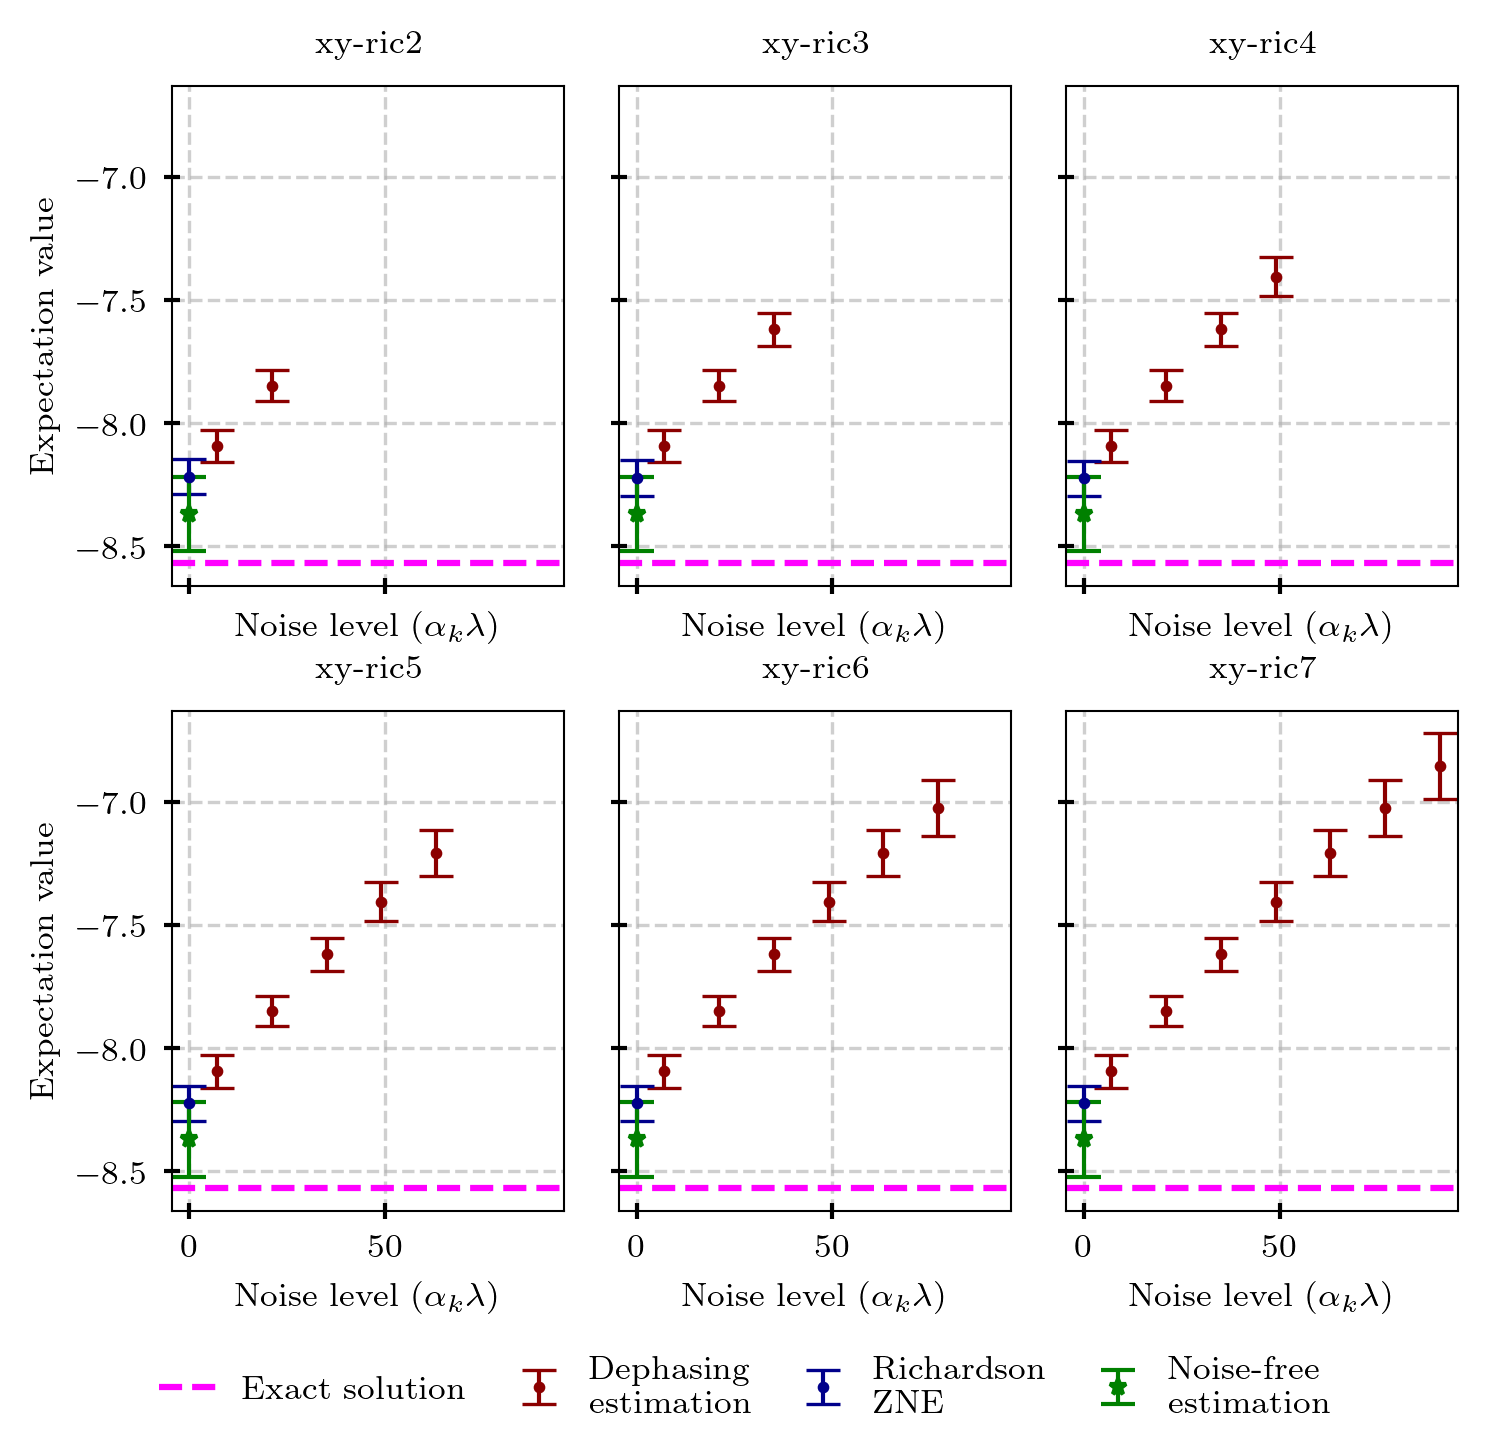

In [20]:
from nbutils.zne_grid_plot import zne_grid

font_size = 8
models_to_plot = ["xy-ric2",
            "xy-ric3",
            "xy-ric4",
            "xy-ric5",
            "xy-ric6",
            "xy-ric7",
]

plot_titles = [
   "xy-ric2",
   "xy-ric3",
   "xy-ric4",
   "xy-ric5",
   "xy-ric6",
   "xy-ric7",
]

zne_grid(
    data=ALL_PROCESSED_DATA,
    models=models_to_plot,
    plot_titles=plot_titles,
    plot_colors=plot_colors,
    exact_solution=EXACT_SOL,
    extrapol_target=EXTRAPOL_TARGET,
    ncols=3,
    figsize=(5, 5),
    sharex=True,
    sharey=True,
    global_legend=True,
    title_fontsize=font_size,
    label_fontsize=font_size,
    tick_fontsize=font_size,
    legend_fontsize=font_size,
    border_width=0.5,
    marker_size=2,
    output_dir=f"reports/{timestamp}/plots",
    filename_prefix="grid_plot",
    leg_noise_type="Dephasing\n"
)

### ric-4 latex table

In [21]:
template_table_ric4 = Template(r"""
\begin{table}
\caption{${caption}}
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}}ll@{}}
\toprule

Noise-free estimation & $$${nf_mean} \pm ${nf_std}$$ \\
\midrule
Base noise=${base_label} & $$${base_mean} \pm ${base_std}$$ \\
Boosted noise=${boost1_label} & $$${boost1_mean} \pm ${boost1_std}$$ \\
Boosted noise=${boost2_label} & $$${boost2_mean} \pm ${boost2_std}$$ \\
Boosted noise=${boost3_label} & $$${boost3_mean} \pm ${boost3_std}$$ \\
\midrule
Richardson ZNE value & $$${zne_mean} \pm ${zne_std}$$ \\
\bottomrule
\end{tabular*}
\label{${label}}
\end{table}
""")


In [22]:
table_ric4_latex = template_table_ric4.substitute(
    caption="Result summary for plots in Figure \ref{plots-depol-time-evo-noisy}.",
    label="table-dephasing-time-evo-noisy",

    # noise free
    nf_mean=f"{ALL_PROCESSED_DATA['xy-ric4']['noiseoff']['mean']:.3f}",
    nf_std=f"{ALL_PROCESSED_DATA['xy-ric4']['noiseoff']['std']:.3f}",

    # noise labels (use strings to ensure safe substitution)
    base_label=str(ALL_PROCESSED_DATA['xy-ric4']['redundant']['sorted_noise_levels'][0]),
    boost1_label=str(ALL_PROCESSED_DATA['xy-ric4']['redundant']['sorted_noise_levels'][1]),
    boost2_label=str(ALL_PROCESSED_DATA['xy-ric4']['redundant']['sorted_noise_levels'][2]),
    boost3_label=str(ALL_PROCESSED_DATA['xy-ric4']['redundant']['sorted_noise_levels'][3]),

    # base
    base_mean=f"{ALL_PROCESSED_DATA['xy-ric4']['redundant']['mean'][0]:.3f}",
    base_std=f"{ALL_PROCESSED_DATA['xy-ric4']['redundant']['std'][0]:.3f}",

    # boosted 1 (index 1)
    boost1_mean=f"{ALL_PROCESSED_DATA['xy-ric4']['redundant']['mean'][1]:.3f}",
    boost1_std=f"{ALL_PROCESSED_DATA['xy-ric4']['redundant']['std'][1]:.3f}",

    # boosted 2 (index 2)
    boost2_mean=f"{ALL_PROCESSED_DATA['xy-ric4']['redundant']['mean'][2]:.3f}",
    boost2_std=f"{ALL_PROCESSED_DATA['xy-ric4']['redundant']['std'][2]:.3f}",

    # boosted 3 (index 3)
    boost3_mean=f"{ALL_PROCESSED_DATA['xy-ric4']['redundant']['mean'][3]:.3f}",
    boost3_std=f"{ALL_PROCESSED_DATA['xy-ric4']['redundant']['std'][3]:.3f}",

    # zne
    zne_mean=f"{ALL_PROCESSED_DATA['xy-ric4']['zne']['mean']:.3f}",
    zne_std=f"{ALL_PROCESSED_DATA['xy-ric4']['zne']['std']:.3f}",
)
print(table_ric4_latex)


\begin{table}
ef{plots-depol-time-evo-noisy}.}s in Figure 
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}}ll@{}}
\toprule

Noise-free estimation & $-8.369 \pm 0.151$ \\
\midrule
Base noise=7 & $-8.093 \pm 0.066$ \\
Boosted noise=21 & $-7.847 \pm 0.062$ \\
Boosted noise=35 & $-7.618 \pm 0.067$ \\
Boosted noise=49 & $-7.405 \pm 0.079$ \\
\midrule
Richardson ZNE value & $-8.223 \pm 0.071$ \\
\bottomrule
\end{tabular*}
\label{table-dephasing-time-evo-noisy}
\end{table}



### compiled-table

In [23]:
template_table_ric_all = Template(r"""
\begin{table}
\caption{${caption}}
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}}ll@{}}
\toprule

Noise-free estimation & $$${nf_mean} \pm ${nf_std}$$ \\
\midrule
Base noise=${base_label} & $$${base_mean} \pm ${base_std}$$ \\
Boosted noise=${boost1_label} & $$${boost1_mean} \pm ${boost1_std}$$ \\
Boosted noise=${boost2_label} & $$${boost2_mean} \pm ${boost2_std}$$ \\
Boosted noise=${boost3_label} & $$${boost3_mean} \pm ${boost3_std}$$ \\
Boosted noise=${boost4_label} & $$${boost4_mean} \pm ${boost4_std}$$ \\
Boosted noise=${boost5_label} & $$${boost5_mean} \pm ${boost5_std}$$ \\
Boosted noise=${boost6_label} & $$${boost6_mean} \pm ${boost6_std}$$ \\
\midrule
2-point Richardson (ric-2) ZNE value & $$${ric2_zne_mean} \pm ${ric2_zne_std}$$ \\
3-point Richardson (ric-3) ZNE value & $$${ric3_zne_mean} \pm ${ric3_zne_std}$$ \\
4-point Richardson (ric-4) ZNE value & $$${ric4_zne_mean} \pm ${ric4_zne_std}$$ \\
5-point Richardson (ric-5) ZNE value & $$${ric5_zne_mean} \pm ${ric5_zne_std}$$ \\
6-point Richardson (ric-6) ZNE value & $$${ric6_zne_mean} \pm ${ric6_zne_std}$$ \\
7-point Richardson (ric-7) ZNE value & $$${ric7_zne_mean} \pm ${ric7_zne_std}$$ \\
\bottomrule
\end{tabular*}
\label{${label}}
\end{table}
""")

table_ric_all_latex = template_table_ric_all.substitute(
    caption=r"Result summary for the plots in Figure \ref{plots-dephasing-time-evo-noisy-all-znes}.",
    label="table-dephasing-noise-free-time-evo",

    nf_mean=f"{ALL_PROCESSED_DATA['xy-ric4']['noiseoff']['mean']:.3f}",
    nf_std=f"{ALL_PROCESSED_DATA['xy-ric4']['noiseoff']['std']:.3f}",

    base_label=str(ALL_PROCESSED_DATA['xy-ric7']['redundant']['sorted_noise_levels'][0]),
    boost1_label=str(ALL_PROCESSED_DATA['xy-ric7']['redundant']['sorted_noise_levels'][1]),
    boost2_label=str(ALL_PROCESSED_DATA['xy-ric7']['redundant']['sorted_noise_levels'][2]),
    boost3_label=str(ALL_PROCESSED_DATA['xy-ric7']['redundant']['sorted_noise_levels'][3]),
    boost4_label=str(ALL_PROCESSED_DATA['xy-ric7']['redundant']['sorted_noise_levels'][4]),
    boost5_label=str(ALL_PROCESSED_DATA['xy-ric7']['redundant']['sorted_noise_levels'][5]),
    boost6_label=str(ALL_PROCESSED_DATA['xy-ric7']['redundant']['sorted_noise_levels'][6]),

    base_mean=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['mean'][0]:.3f}",
    base_std=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['std'][0]:.3f}",
    boost1_mean=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['mean'][1]:.3f}",
    boost1_std=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['std'][1]:.3f}",
    boost2_mean=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['mean'][2]:.3f}",
    boost2_std=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['std'][2]:.3f}",
    boost3_mean=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['mean'][3]:.3f}",
    boost3_std=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['std'][3]:.3f}",
    boost4_mean=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['mean'][4]:.3f}",
    boost4_std=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['std'][4]:.3f}",
    boost5_mean=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['mean'][5]:.3f}",
    boost5_std=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['std'][5]:.3f}",
    boost6_mean=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['mean'][6]:.3f}",
    boost6_std=f"{ALL_PROCESSED_DATA['xy-ric7']['redundant']['std'][6]:.3f}",

    # Richardson ZNE values for each ric-N (filled from ALL_PROCESSED_DATA)
    ric2_zne_mean=f"{ALL_PROCESSED_DATA['xy-ric2']['zne']['mean']:.3f}",
    ric2_zne_std=f"{ALL_PROCESSED_DATA['xy-ric2']['zne']['std']:.3f}",
    ric3_zne_mean=f"{ALL_PROCESSED_DATA['xy-ric3']['zne']['mean']:.3f}",
    ric3_zne_std=f"{ALL_PROCESSED_DATA['xy-ric3']['zne']['std']:.3f}",
    ric4_zne_mean=f"{ALL_PROCESSED_DATA['xy-ric4']['zne']['mean']:.3f}",
    ric4_zne_std=f"{ALL_PROCESSED_DATA['xy-ric4']['zne']['std']:.3f}",
    ric5_zne_mean=f"{ALL_PROCESSED_DATA['xy-ric5']['zne']['mean']:.3f}",
    ric5_zne_std=f"{ALL_PROCESSED_DATA['xy-ric5']['zne']['std']:.3f}",
    ric6_zne_mean=f"{ALL_PROCESSED_DATA['xy-ric6']['zne']['mean']:.3f}",
    ric6_zne_std=f"{ALL_PROCESSED_DATA['xy-ric6']['zne']['std']:.3f}",
    ric7_zne_mean=f"{ALL_PROCESSED_DATA['xy-ric7']['zne']['mean']:.3f}",
    ric7_zne_std=f"{ALL_PROCESSED_DATA['xy-ric7']['zne']['std']:.3f}",
)

print(table_ric_all_latex)


\begin{table}
\caption{Result summary for the plots in Figure \ref{plots-dephasing-time-evo-noisy-all-znes}.}
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}}ll@{}}
\toprule

Noise-free estimation & $-8.369 \pm 0.151$ \\
\midrule
Base noise=7 & $-8.093 \pm 0.066$ \\
Boosted noise=21 & $-7.847 \pm 0.062$ \\
Boosted noise=35 & $-7.618 \pm 0.067$ \\
Boosted noise=49 & $-7.405 \pm 0.079$ \\
Boosted noise=63 & $-7.207 \pm 0.095$ \\
Boosted noise=77 & $-7.024 \pm 0.113$ \\
Boosted noise=91 & $-6.854 \pm 0.132$ \\
\midrule
2-point Richardson (ric-2) ZNE value & $-8.216 \pm 0.071$ \\
3-point Richardson (ric-3) ZNE value & $-8.223 \pm 0.071$ \\
4-point Richardson (ric-4) ZNE value & $-8.223 \pm 0.071$ \\
5-point Richardson (ric-5) ZNE value & $-8.223 \pm 0.071$ \\
6-point Richardson (ric-6) ZNE value & $-8.223 \pm 0.071$ \\
7-point Richardson (ric-7) ZNE value & $-8.223 \pm 0.071$ \\
\bottomrule
\end{tabular*}
\label{table-dephasing-noise-free-time-evo}
\end{table}



### File writing for latex tables

In [24]:
# Ensure artifact dir exists
os.makedirs(artifact_dir, exist_ok=True)

to_write = {}

if "table_ric4_latex" in globals():
    to_write[os.path.join(artifact_dir, "table_ric4.tex")] = table_ric4_latex

if "table_ric_all_latex" in globals():
    to_write[os.path.join(artifact_dir, "table_ric_all.tex")] = table_ric_all_latex

# Write files
for out_path, content in to_write.items():
    with open(out_path, "w", encoding="utf-8") as fh:
        fh.write(content.lstrip())
    print("Wrote LaTeX table to:", out_path)

Wrote LaTeX table to: reports/20260323-122557/artifacts/table_ric4.tex
Wrote LaTeX table to: reports/20260323-122557/artifacts/table_ric_all.tex
